In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import random
import os

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [2]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessicali9530/celeba-dataset")

print("Path to dataset files:", path)

100%|██████████| 1.33G/1.33G [00:33<00:00, 42.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/jessicali9530/celeba-dataset/versions/2


In [4]:
# Asegúrate de definir DATA_DIR y IMAGE_SIZE antes de instanciar el dataset
DATA_DIR = os.path.join(path, 'img_align_celeba', 'img_align_celeba') # Ruta típica de Kaggle
IMAGE_SIZE = 64

In [5]:
class CelebADataset(Dataset):
    def __init__(self, data_dir, image_size=64):
        self.data_dir = data_dir
        self.img_files = sorted([f for f in os.listdir(data_dir) if f.endswith('.jpg')])[:50000]
        self.transform = transforms.Compose([
            transforms.Resize(image_size),#escala la imagen a 64
            transforms.CenterCrop(image_size),#recorta a cuadrado de 64x64
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        ])

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        img = Image.open(os.path.join(self.data_dir, self.img_files[idx])).convert('RGB')
        return self.transform(img), 0

train = CelebADataset(DATA_DIR, IMAGE_SIZE)
len(train)

50000

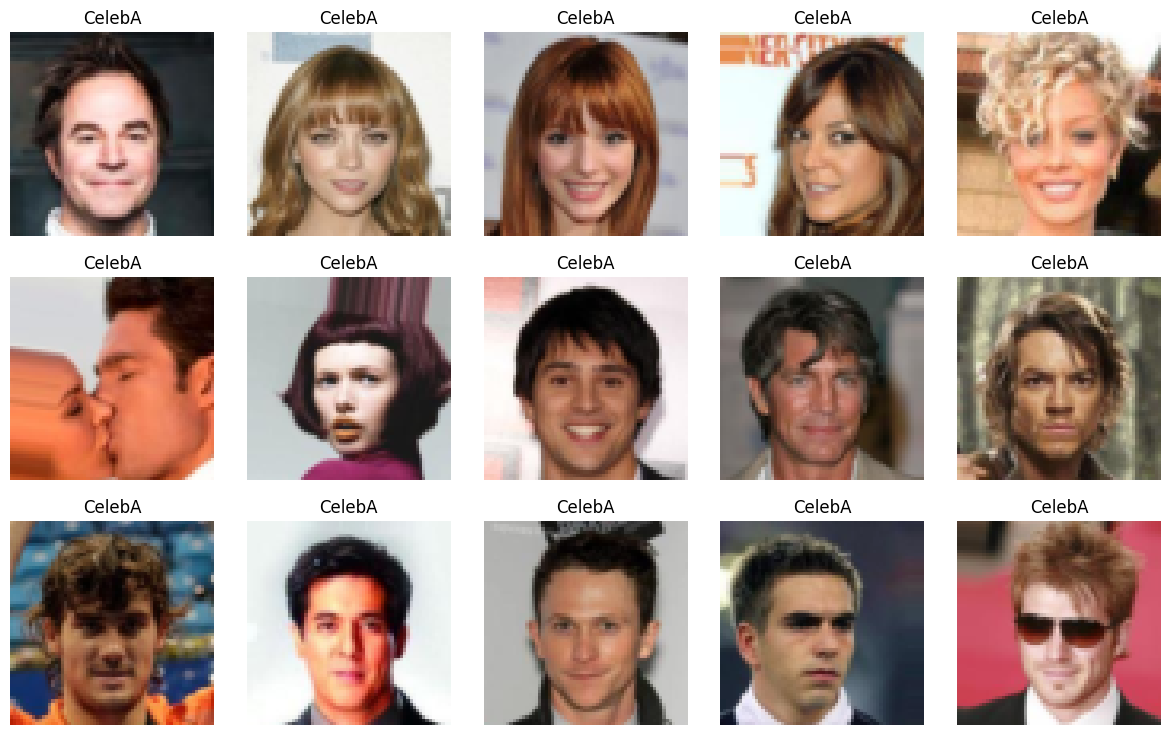

In [6]:
dataloader = DataLoader(train, batch_size=128, shuffle=True)
# batch=128
# batches más grandes dan gradientes más estables
# el discriminador ve más variedad por actualización

def denorm(tensor):
    return (tensor * 0.5 + 0.5).clamp(0, 1)

r, c = 3, 5
plt.figure(figsize=(c*3, r*3))
for row in range(r):
    for col in range(c):
        plt.subplot(r, c, c*row + col + 1)
        img, _ = train[random.randint(0, len(train)-1)]
        plt.imshow(denorm(img).permute(1, 2, 0))
        plt.axis('off')
        plt.title("CelebA")
plt.subplots_adjust(wspace=0.1, hspace=0.2)
plt.show()

In [7]:
class Generator(nn.Module):
    def __init__(self, nz=100, ngf=64):#vector de ruido aleatorio, Multiplicador de profundidad de filtros
        super().__init__()
        self.input_size = nz
        self.main = nn.Sequential(
            # entrada: vector nz → mapa 4x4
            nn.ConvTranspose2d(nz, ngf*8, 4, 1, 0, bias=False),#Kernel Size, Stride, padding, Tiene 512 filtros (ngf*8) para captar formas muy abstractas
            nn.BatchNorm2d(ngf*8),#normaliza cada canal (o mapa de características) de forma independiente media 0 y  desviacion 1
            nn.ReLU(True),
            # 4x4 → 8x8
            #CAPA 2: De 4x4 sube a 8x8 píxeles.
            #Los filtros bajan a 256 (ngf*4)
            nn.ConvTranspose2d(ngf*8, ngf*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*4),
            nn.ReLU(True),#Una función que deja pasar los valores positivos y apaga los negativos, ayudando a la red a aprender patrones complejos
            # CAPA 3: De 8x8 sube a 16x16 píxeles.
            # Los filtros bajan a 128 (ngf*2). La imagen gana resolución y pierde "grosor".
            nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*2),#Aprende dos parámetros porfiltro:Gamma(para escalar) y Beta(para desplazar),cuál es el rango de valores óptimo para generar la imagen más realista
            nn.ReLU(True),
            # 16x16 → 32x32
            nn.ConvTranspose2d(ngf*2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            # 32x32 → 64x64
            nn.ConvTranspose2d(ngf, 3, 4, 2, 1, bias=False),#Los canales pasan de 64 a 3 (Rojo, Verde y Azul para formar la imagen final).
            nn.Tanh()#Comprime todos los valores de salida entre -1 y 1. Esto es lo que el Generador entrega como "imagen final"
            #debe coincidir con los datos de entrenamiento reales
        )

        def forward(self, x):  # x llega como una lista plana de 100 números (ruido).
        x = x.view(x.size(0), self.input_size, 1, 1)#.view cambia las dimensiones a 4D para que pase por ConvTranspose2d

        return self.main(x)# esa lista de 4D pasa (1x1 hasta 64x64)Al final, devuelve la imagen generada lista para mostrarse.




In [9]:
class Discriminator(nn.Module):
    def __init__(self, ndf=64):
        super().__init__()
        self.main = nn.Sequential(
            # ENTRADA: Imagen de 64x64 con 3 canales (RGB).
            # CAPA 1: 64x64 -> 32x32. No usa BatchNorm para no sesgar la entrada real.
            nn.Conv2d(3, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),#deja pasar un pequeño gradiente

            # CAPA 2: 32x32 -> 16x16. Aumentamos filtros a 128 (ndf*2).
            nn.Conv2d(ndf, ndf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*2),
            nn.LeakyReLU(0.2, inplace=True),

            # CAPA 3: 16x16 -> 8x8. Aumentamos filtros a 256 (ndf*4).
            nn.Conv2d(ndf*2, ndf*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*4),
            nn.LeakyReLU(0.2, inplace=True),

            # CAPA 4: 8x8 -> 4x4. Aumentamos filtros a 512 (ndf*8).
            nn.Conv2d(ndf*4, ndf*8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*8),
            nn.LeakyReLU(0.2, inplace=True),

            # CAPA 5 (SALIDA): 4x4 -> 1x1.
            # El resultado final es un solo número por imagen.
            nn.Conv2d(ndf*8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()#Comprime el valor escalar al rango [0,1]. 0 significa "falsa" y 1 significa "real". Es la probabilidad que asigna el Discriminador.
        )

    def forward(self, x):
        # El resultado sale como un bloque de [Batch, 1, 1, 1].
        return self.main(x).view(-1, 1)# .view(-1, 1) lo aplana para que sea solo una lista de puntajes (ej: 0.95).


In [12]:
def fit(g, d, dataloader, epochs=30):
    # Inicialización de optimizadores Adam con hiperparámetros de DCGAN (lr=0.0002, beta1=0.5)
    g_optimizer = torch.optim.Adam(g.parameters(), lr=2e-4, betas=(0.5, 0.999))
    d_optimizer = torch.optim.Adam(d.parameters(), lr=2e-4, betas=(0.5, 0.999))

    # Definición de la función de pérdida: Entropía Cruzada Binaria para clasificación
    crit = nn.BCELoss()
    # Diccionario para el seguimiento de la convergencia de las funciones de coste
    hist = {'g_loss': [], 'd_loss': []}

    # Configuración de los módulos en modo entrenamiento (activa BatchNorm y Dropout)
    g.train()
    d.train()

    for epoch in range(1, epochs+1):
        g_losses, d_losses = [], []

        for X, _ in dataloader:#itera sobre los batches donde x son img reales

            X = X.to(device)# Transferencia de tensores al dispositivo de cómputo (GPU/CPU)

            bs = X.size(0)#Guarda el tamaño del batch

            # ── FASE 1: Optimización del Discriminador (D) ─────────────────────────────

            d.zero_grad()#Limpia los gradientes acumulados del discriminador antes de calcular los nuevos

            # 1.1 Evaluación de imágenes reales con Label Smoothing (0.9 en lugar de 1.0)

            label_real = torch.ones(bs, 1).to(device) * 0.9 # Esto reduce la varianza del gradiente y evita el sobreajuste del discriminador
            out_real = d(X)#le pasa al discriminador las entradas, compara la salida real con la del discriminador
            d_real_loss = crit(out_real, label_real)#compara diferencia de perdidas reales con las etiquetas reales
            # Cálculo de gradientes para datos reales
            d_real_loss.backward()# el calculo de ajuste de gradientes

            # 1.2 Evaluación de imágenes sintéticas (generadas a partir de ruido latente)
            noise = torch.randn(bs, g.input_size).to(device)#ruido inicial que a partir de ese ruido genere una imagen
            fake = g(noise)#guarda los vectores o salida del generador que representa una imagen falsa en una variable llamada fake
            label_fake = torch.zeros(bs, 1).to(device)#agrega zeros en la columna 1 dependeindo el batchsize porque son falsas

            out_fake = d(fake.detach())##fake fueron creadas por el Generador. Al usar .detach(), estamos "cortando" la conexión con el grafo computacional del Generado

            d_fake_loss = crit(out_fake, label_fake)#calcula error del discriminador frente a las imagenes sinteticas
            d_fake_loss.backward()# Cálculo de gradientes para datos falsos (acumulación por aditividad)

            # Actualización de pesos del Discriminador mediante el optimizador Adam
            d_optimizer.step()
            d_losses.append(d_real_loss.item() + d_fake_loss.item())

            # ── FASE 2: Optimización del Generador (G) ─────────────────────────────────
            # El objetivo es maximizar la probabilidad de que D clasifique lo falso como real
            g.zero_grad()

            # Etiqueta objetivo: 1 (G intenta "engañar" a D haciéndose pasar por real)
            label_g = torch.ones(bs, 1).to(device)
            # Re-evaluación en D sin detach() para permitir el flujo del gradiente hacia G
            out_fake_g = d(fake)
            g_l = crit(out_fake_g, label_g)
            # Retropropagación del error a través de D hasta los parámetros de G
            g_l.backward()#backpropagation reajusta los pesos del generador

            # Actualización de pesos del Generador
            g_optimizer.step()
            g_losses.append(g_l.item())#guarda las erdidas para mostrar

        # Cálculo y registro de la pérdida media por época
        hist['g_loss'].append(np.mean(g_losses))
        hist['d_loss'].append(np.mean(d_losses))
        print(f'Epoch {epoch}/{epochs} g_loss {np.mean(g_losses):.5f} d_loss {np.mean(d_losses):.5f}')

    return hist

# Instanciación de arquitecturas y transferencia a memoria de video (VRAM)
generator = Generator().to(device)
discriminator = Discriminator().to(device)

# Inicio del proceso de entrenamiento adversarial
hist = fit(generator, discriminator, dataloader, epochs=30)

Epoch 1/30 g_loss 6.28553 d_loss 0.80401
Epoch 2/30 g_loss 4.52833 d_loss 0.76265
Epoch 3/30 g_loss 4.36027 d_loss 0.72087
Epoch 4/30 g_loss 3.92300 d_loss 0.76901
Epoch 5/30 g_loss 3.73271 d_loss 0.78325
Epoch 6/30 g_loss 3.54240 d_loss 0.79419
Epoch 7/30 g_loss 3.23041 d_loss 0.79040
Epoch 8/30 g_loss 2.92648 d_loss 0.82526
Epoch 9/30 g_loss 2.76143 d_loss 0.88048
Epoch 10/30 g_loss 2.65100 d_loss 0.88888
Epoch 11/30 g_loss 2.52958 d_loss 0.89512
Epoch 12/30 g_loss 2.49795 d_loss 0.90772
Epoch 13/30 g_loss 2.44480 d_loss 0.90098
Epoch 14/30 g_loss 2.48332 d_loss 0.88942
Epoch 15/30 g_loss 2.47282 d_loss 0.87923
Epoch 16/30 g_loss 2.44781 d_loss 0.89454
Epoch 17/30 g_loss 2.53487 d_loss 0.85340
Epoch 18/30 g_loss 2.44278 d_loss 0.90080
Epoch 19/30 g_loss 2.47496 d_loss 0.87300
Epoch 20/30 g_loss 2.53679 d_loss 0.84082
Epoch 21/30 g_loss 2.62480 d_loss 0.83376
Epoch 22/30 g_loss 2.57861 d_loss 0.85342
Epoch 23/30 g_loss 2.62362 d_loss 0.83305
Epoch 24/30 g_loss 2.66231 d_loss 0.79889
E

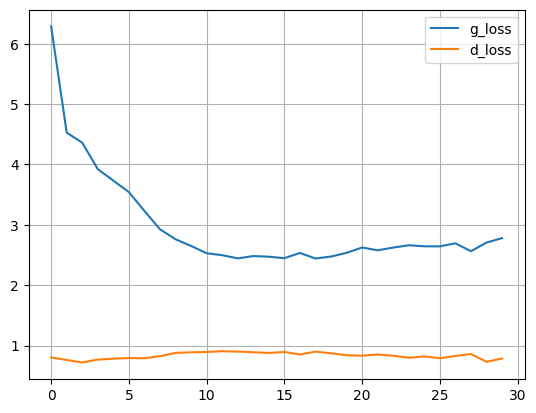

In [13]:
import pandas as pd

df = pd.DataFrame(hist)
df.plot(grid=True)
plt.show()

el generador y el discrminador se van encontrando porque el generador aprende a generar buenas imaganes y el discriminador le cuesta distinguir

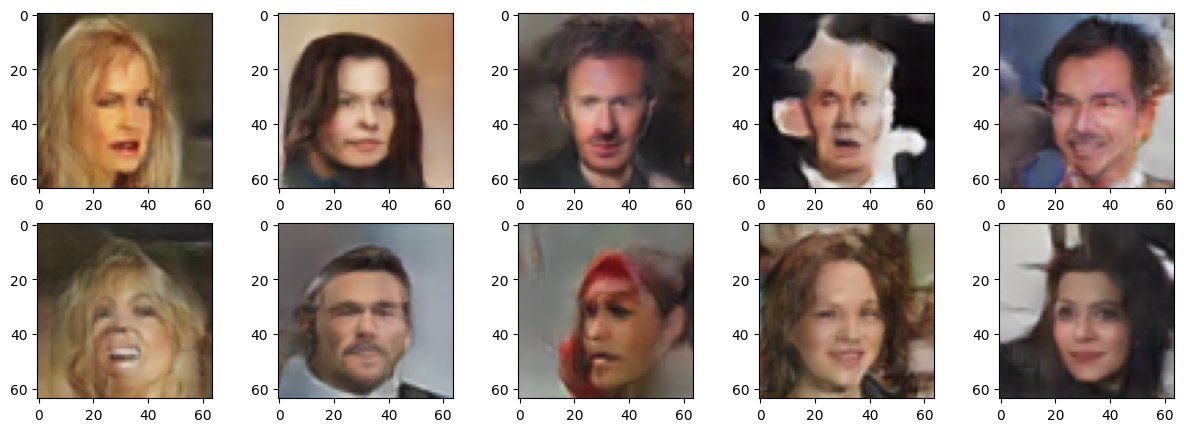

In [15]:
generator.eval()
with torch.no_grad():
    noise = torch.randn(10, generator.input_size).to(device)
    generated_images = generator(noise)
    fig, axs = plt.subplots(2, 5, figsize=(15, 5))
    i = 0
    for ax in axs:
        for _ax in ax:
            img = denorm(generated_images[i]).permute(1, 2, 0).cpu()
            _ax.imshow(img)
            i += 1
    plt.show()